In [38]:
import pandas as pd

In [39]:
# seed3つの平均スコアを計算する関数
def get_avg_score(df):
    df["model"] = df["name"].str.replace(r"_seed\d+", "", regex=True)
    df_avg=df.groupby("model").mean(numeric_only=True).reset_index()
    return df_avg

In [40]:
# mlpのparamsを計算する関数
def mlp_params(input_dim,output_dim):
    # hidden size 1024, layers 2
    hidden_size = 1024
    layer1 = (input_dim * hidden_size) + hidden_size
    layer2 = (hidden_size * hidden_size) + hidden_size
    layer3 = (hidden_size * output_dim) + output_dim
    params = layer1 + layer2 + layer3
    return params

In [41]:
# rnnのparamsを計算する関数
def rnn_params(input_dim,output_dim):
    # hidden size 400, layers 2, LSTM Cell
    hidden_size = 400
    layer1 = 4 * ((input_dim + hidden_size) * hidden_size + hidden_size)
    layer2 = 4 * ((hidden_size + hidden_size) * hidden_size + hidden_size)
    layer3 = (hidden_size * output_dim) + output_dim
    params = layer1 + layer2 + layer3
    return params

In [42]:
# ncpのparamsを計算する関数
def ncp_params(input_dim, output_dim, units):
    layer1 = (input_dim * units) + units
    params_1 = units * 3 #gleak,vleak,cm
    params_2 = units * units * 5 # sigma, mu, w, erev, sparsity_mask
    params_3 = input_dim * units * 5 # sensory_sigma, sensory_mu, sensory_w, sensory_erev, sensory_sparsity_mask
    layer2 = (units * output_dim) + output_dim
    params = layer1 + params_1 + params_2 + params_3 + layer2
    return params

In [43]:
import re
def calculate_model_size(df, task):
    df = df.copy()
    if task == "lift": #[10,3,4,2]
        input_dim = 19
        output_dim = 7
    elif task == "can": #[14,3,4,2]
        input_dim = 23
        output_dim = 7
    elif task == "square": #[14,3,4,2]
        input_dim = 23
        output_dim = 7
    else:
        raise ValueError("Unknown task")
    for model in df["model"].unique():
        idx = df["model"] == model
        if model == "bc-pure":
            df.loc[idx, "params"] = mlp_params(input_dim,output_dim)
        elif model == "bc-rnn-pure":
            df.loc[idx, "params"] = rnn_params(input_dim,output_dim)
        elif model.startswith("ncp"):
            u = int(re.search(r"_u(\d+)", model).group(1))
            df.loc[idx, "params"] = ncp_params(input_dim,output_dim,u)
        else:
            raise ValueError("Unknown model")
    return df

In [44]:
df_lift=pd.read_csv('/work/robomimic/csv/lift/lift-best.csv')
df_can=pd.read_csv('/work/robomimic/csv/can/can-best.csv')
df_square=pd.read_csv('/work/robomimic/csv/square/square-best.csv')
df_can_avg=get_avg_score(df_can)
df_can_avg=calculate_model_size(df_can_avg, "can")
df_lift_avg=get_avg_score(df_lift)
df_lift_avg=calculate_model_size(df_lift_avg, "lift")
df_square_avg=get_avg_score(df_square)
df_square_avg=calculate_model_size(df_square_avg, "square")

In [45]:
print(df_square_avg[["model","params","return","avg_policy_latency_ms", "avg_gpu_memory_increase_mb"]])

           model     params    return  avg_policy_latency_ms  \
0        bc-pure  1081351.0  0.390000               0.875822   
1    bc-rnn-pure  1962807.0  0.670000               1.152379   
2  ncp_u128_best   100999.0  0.453333               1.355979   
3  ncp_u256_best   365831.0  0.600000               1.042837   
4  ncp_u512_best  1387015.0  0.566667               1.056882   

   avg_gpu_memory_increase_mb  
0                   25.626953  
1                   39.490214  
2                    1.341309  
3                    4.924805  
4                   18.841797  


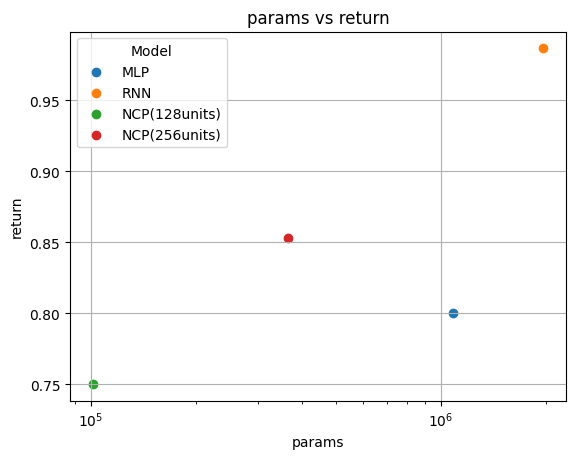

In [46]:
import matplotlib.pyplot as plt

model_display_names = {
    "bc-pure": "MLP",
    "bc-rnn-pure": "RNN",
    "ncp_u128_best": "NCP(128units)",
    "ncp_u256_best": "NCP(256units)",
    "ncp_u512_best": "NCP(512units)",
}

plt.figure()

for model in df_can_avg["model"].unique():
    df_m = df_can_avg[df_can_avg["model"] == model]
    display_name = model_display_names.get(model, model)
    plt.scatter(df_m["params"], df_m["return"], label=display_name)

plt.xlabel("params")
plt.xscale("log")
plt.ylabel("return")
plt.title("params vs return")
plt.legend(title="Model")
plt.grid(True)
plt.show()

In [47]:
df_lift_filtered = df_lift_avg[~df_lift_avg["model"].str.contains("u512")]
print(df_lift_filtered)

           model    return    horizon  success_rate  avg_policy_latency_ms  \
0        bc-pure  0.970000  57.546667      0.970000               0.891192   
1    bc-rnn-pure  1.000000  43.866667      1.000000               1.180347   
2  ncp_u128_best  0.970000  59.236667      0.970000               1.817892   
3  ncp_u256_best  0.993333  48.603333      0.993333               1.820828   

   std_policy_latency_ms  avg_env_step_time_ms  std_env_step_time_ms  \
0               0.151891             10.974267              0.771974   
1               0.182066             10.897139              0.555644   
2               0.117102             10.851356              0.679237   
3               0.125891             10.882162              0.670693   

   avg_step_latency_ms  std_step_latency_ms  avg_gpu_memory_increase_mb  \
0            13.424223             0.868868                   25.564453   
1            13.643867             0.661010                   39.415182   
2            14.229497 

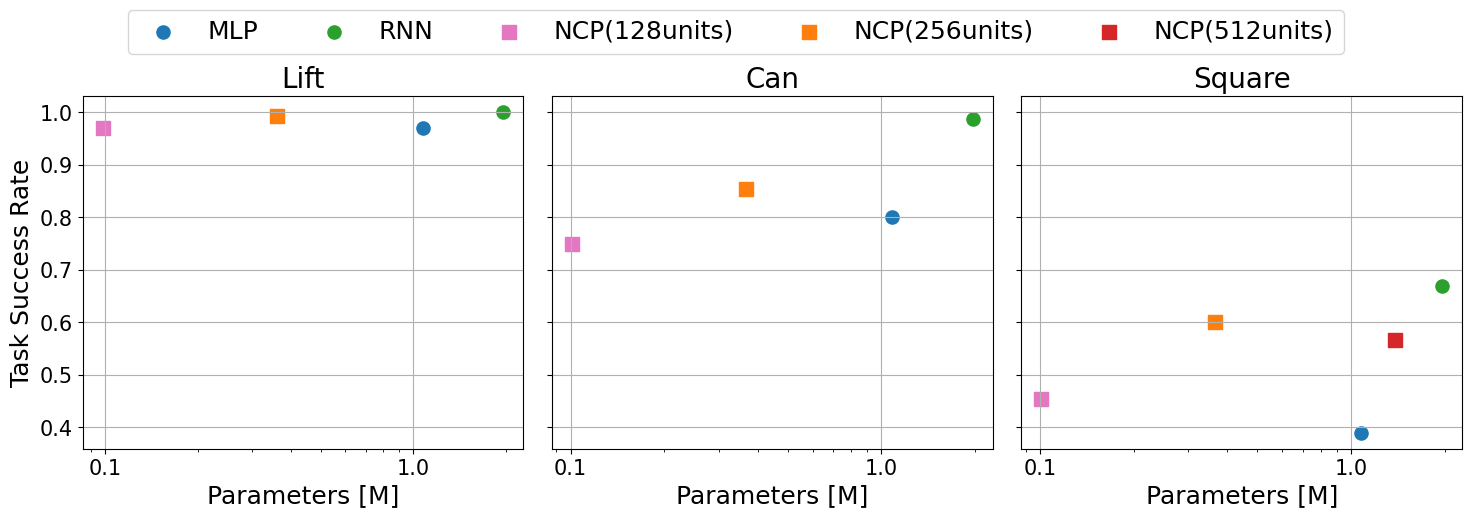

In [58]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    "font.size": 16,         # 全体のフォントサイズ
    "axes.labelsize": 18,    # 軸ラベル
    "axes.titlesize": 20,    # タイトル
    "legend.fontsize": 15,   # 凡例
    "xtick.labelsize": 15,   # x軸目盛
    "ytick.labelsize": 15    # y軸目盛
})

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

datasets = {
    "Lift": df_lift_filtered,
    "Can": df_can_avg,
    "Square": df_square_avg
}

# ---- 追加：カラーパレット ----
custom_colors = [
    "#1f77b4",  # 青
    "#2ca02c",  # 緑
    "#e377c2",  # ピンク
    "#ff7f0e",  # オレンジ
    "#d62728",  # 赤
    "#bcbd22",  # 黄土
    "#9467bd",  # 紫
    "#8c564b",  # 茶
    "#7f7f7f",  # グレー
    "#17becf"   # シアン
]

model_styles = {}

def get_style(model):
    if model not in model_styles:
        color = custom_colors[len(model_styles) % len(custom_colors)]
        marker = "s" if "ncp" in model.lower() else "o"
        model_styles[model] = {"color": color, "marker": marker}
    return model_styles[model]

for ax, (title, df) in zip(axes, datasets.items()):
    for model in df["model"].unique():
        sub = df[df["model"] == model]
        style = get_style(model)
        size = 90 if "ncp" in model.lower() else 90
        display_name = model_display_names.get(model, model)

        ax.scatter(
            sub["params"],
            sub["success_rate"],
            label=display_name,
            s=size,
            color=style["color"],
            marker=style["marker"]
        )

    ax.set_title(title)
    ax.set_xscale("log")
    ax.set_xlabel("Parameters [M]")
    ax.grid(True)

axes[0].set_ylabel("Task Success Rate")

for ax in axes:
    ax.xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}")
    )

handles, labels = axes[2].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.07),  # さらに上に配置
    ncol=len(labels),            # 横並び
    frameon=True,
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.98])  # 下を少し縮めて上の余白を確保
plt.show()
